In [ ]:
#  IMPORTS
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

In [25]:
df= pd.read_csv("emails.csv")
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [27]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(33)

In [29]:
df= df.drop_duplicates()

In [30]:
df.shape

(5695, 2)

In [31]:
# CHECK CLASS DISTRIBUTION FIRST
print("Class distribution:")
print(df['spam'].value_counts())
print(f"Spam ratio: {df['spam'].mean():.2%}")

Class distribution:
spam
0    4327
1    1368
Name: count, dtype: int64
Spam ratio: 24.02%


In [32]:
#TF-IDF VECTORIZATION
tfidf = TfidfVectorizer(
    min_df=2,          # ignore very rare terms
    max_df=0.95,       # ignore overly common terms
    sublinear_tf=True  # apply log normalization
)
X = tfidf.fit_transform(df['text'].values.astype('U'))
y = df['spam'].values
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (5695, 20249)


In [33]:
#SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
# Option 1: ComplementNB (designed for imbalanced text classification)
model = ComplementNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,norm,False


In [36]:
y_proba = model.predict_proba(X_test)[:, 1]  # probability of spam

In [37]:
# Find threshold that balances precision/recall
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
# Pick threshold closest to top-left corner of ROC curve
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.3f}")

y_pred_default   = (y_proba >= 0.5).astype(int)
y_pred_optimized = (y_proba >= optimal_threshold).astype(int)

Optimal threshold: 0.215


In [38]:
# COMPARE RESULTS
print("\n--- Default threshold (0.5) ---")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default, target_names=['Not Spam', 'Spam']))

print(f"\n--- Optimized threshold ({optimal_threshold:.3f}) ---")
print(confusion_matrix(y_test, y_pred_optimized))
print(classification_report(y_test, y_pred_optimized, target_names=['Not Spam', 'Spam']))



--- Default threshold (0.5) ---
[[865   0]
 [ 34 240]]
              precision    recall  f1-score   support

    Not Spam       0.96      1.00      0.98       865
        Spam       1.00      0.88      0.93       274

    accuracy                           0.97      1139
   macro avg       0.98      0.94      0.96      1139
weighted avg       0.97      0.97      0.97      1139


--- Optimized threshold (0.215) ---
[[855  10]
 [  5 269]]
              precision    recall  f1-score   support

    Not Spam       0.99      0.99      0.99       865
        Spam       0.96      0.98      0.97       274

    accuracy                           0.99      1139
   macro avg       0.98      0.99      0.98      1139
weighted avg       0.99      0.99      0.99      1139



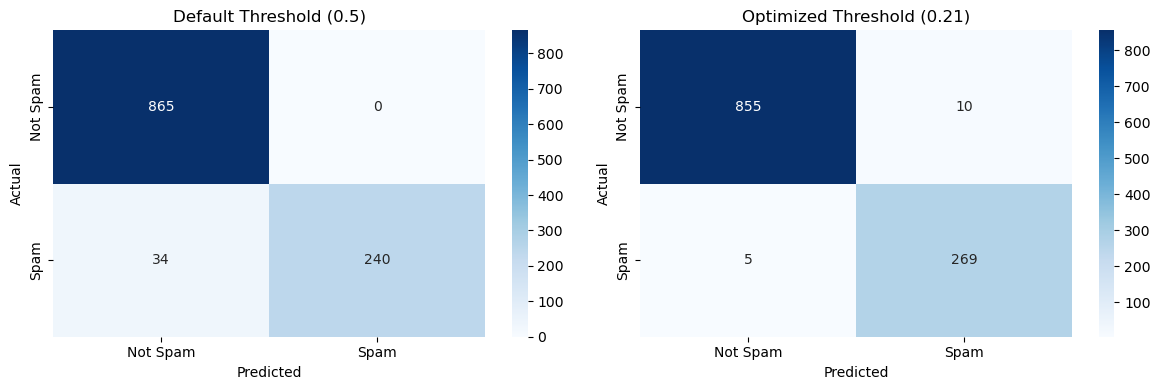

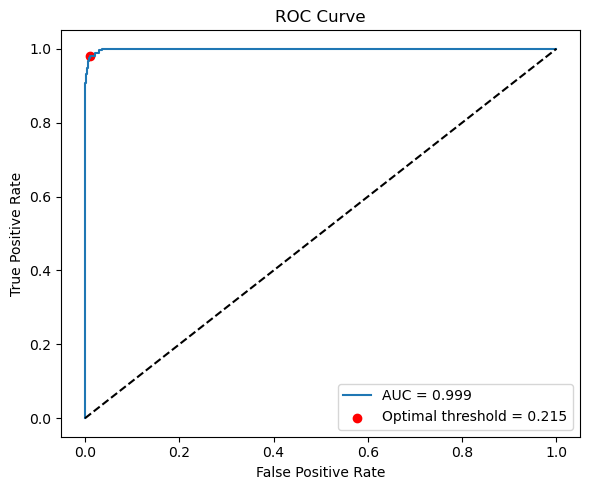

In [39]:
# VISUALIZE BOTH CONFUSION MATRICES
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [y_pred_default, y_pred_optimized],
    ['Default Threshold (0.5)', f'Optimized Threshold ({optimal_threshold:.2f})']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Spam', 'Spam'],
                yticklabels=['Not Spam', 'Spam'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# ── ROC CURVE ─────────────────────────────────────────
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', 
            label=f'Optimal threshold = {optimal_threshold:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# PREDICT FROM USER INPUT
def predict_message(message, model, tfidf):
    # Transform the input using the already-fitted tfidf
    message_transformed = tfidf.transform([message])
    
    # Get prediction and probability
    prediction = model.predict(message_transformed)[0]
    probability = model.predict_proba(message_transformed)[0]
    
    spam_prob  = probability[1] * 100
    not_spam_prob   = probability[0] * 100
    
    print("\n" + "="*50)
    print(f"Message: {message}")
    print(f"{'='*50}")
    print(f"Prediction : {'🚨 SPAM' if prediction == 1 else '✅  Not Spam'}")
    print(f"Spam  Prob : {spam_prob:.2f}%")
    print(f"Not spam   Prob : {not_spam_prob:.2f}%")
    print("="*50)
    
    return prediction, spam_prob

In [46]:
# SINGLE MESSAGE TEST
user_message = input("Enter a message to check: ")
predict_message(user_message, model, tfidf)

Enter a message to check:  Hi! you are been selected for the data scientist job.



Message: Hi! you are been selected for the data scientist job.
Prediction : ✅  Not Spam
Spam  Prob : 13.86%
Not spam   Prob : 86.14%


(np.int64(0), np.float64(13.859179299828394))

In [47]:
# MULTIPLE MESSAGES IN A LOOP
print("\n--- Batch Mode (type 'quit' to exit) ---")
while True:
    user_input = input("\nEnter message: ").strip()
    
    if user_input.lower() == 'quit':
        print("Exiting...")
        break
    
    if not user_input:
        print("Please enter a valid message.")
        continue
        
    predict_message(user_input, model, tfidf)


--- Batch Mode (type 'quit' to exit) ---



Enter message:  hi



Message: hi
Prediction : ✅  Not Spam
Spam  Prob : 16.98%
Not spam   Prob : 83.02%



Enter message:  hello! congratulations for your selection for job.



Message: hello! congratulations for your selection for job.
Prediction : ✅  Not Spam
Spam  Prob : 25.47%
Not spam   Prob : 74.53%



Enter message:  quit


Exiting...


In [48]:
import pickle

#SAVE MODEL AND VECTORIZER
with open('spam_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [49]:
# LOAD MODEL AND VECTORIZER
with open('spam_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

print("Model and vectorizer loaded successfully!")

Model and vectorizer loaded successfully!
